In [10]:
!pip install transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [11]:
from datasets import load_dataset

dataset = load_dataset("go_emotions")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [12]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Load tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Load model
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=28,
    problem_type="multi_label_classification"
)

print("Multi-label RoBERTa Ready")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Multi-label RoBERTa Ready


### Tokenization Function

Now, let's define a tokenization function to process the text data using the `RoBERTaTokenizer` and then apply it to the dataset.

In [13]:
# Tokenization Function
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Apply Tokenization
tokenized_datasets = dataset.map(tokenize_function, batched=True)

print(tokenized_datasets)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id', 'input_ids', 'attention_mask'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id', 'input_ids', 'attention_mask'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id', 'input_ids', 'attention_mask'],
        num_rows: 5427
    })
})


### Preprocessing Labels for Multi-Label Classification

Since this is a multi-label classification task and the original `labels` can be lists of varying lengths, we need to convert them into a fixed-size, multi-hot encoded format. This ensures that all label tensors have the same dimension for batching during training.

In [14]:
import torch

# Get the number of possible labels from the model configuration
num_labels = model.config.num_labels

def preprocess_labels(example):
    # Create a zero tensor of size num_labels
    multihot_labels = torch.zeros(num_labels, dtype=torch.float)
    # Set 1 for each present label
    for label_id in example["labels"]:
        multihot_labels[label_id] = 1.0
    return {"labels": multihot_labels}

# Apply the preprocessing function to the dataset
tokenized_datasets = tokenized_datasets.map(preprocess_labels, batched=False)

print("Labels preprocessed for multi-hot encoding.")
print(tokenized_datasets)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Labels preprocessed for multi-hot encoding.
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id', 'input_ids', 'attention_mask'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id', 'input_ids', 'attention_mask'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id', 'input_ids', 'attention_mask'],
        num_rows: 5427
    })
})


In [15]:
from datasets import Sequence, Value

# Get the number of possible labels from the model configuration
num_labels = model.config.num_labels

# Update the features schema for 'labels' to reflect multi-hot encoded float tensors.
# This is crucial for the Trainer to correctly interpret the label type.
new_features = tokenized_datasets["train"].features.copy()
new_features["labels"] = Sequence(feature=Value(dtype='float32', id=None), length=num_labels)

# Apply a no-op map to update the dataset's schema with the new features
tokenized_datasets = tokenized_datasets.map(
    lambda x: x,
    features=new_features,
    batched=True # Use batched=True for performance, even with a no-op
)

print("Dataset features schema for 'labels' updated to Sequence[float32].")
print(tokenized_datasets["train"].features)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Dataset features schema for 'labels' updated to Sequence[float32].
{'text': Value('string'), 'labels': List(Value('float32'), length=28), 'id': Value('string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


### Set Format for PyTorch

Now, let's set the format of the tokenized dataset to PyTorch tensors, which is necessary for training with PyTorch-based models.

In [16]:
tokenized_datasets.set_format(
        type="torch",
            columns=["input_ids", "attention_mask", "labels"]
)

print("Dataset formatted for PyTorch successfully")

Dataset formatted for PyTorch successfully


### Training Arguments

Next, we'll define the `TrainingArguments` for our model. These arguments control various aspects of the training process, such as batch size, learning rate, and evaluation strategy.

In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    fp16=True # Changed to True for faster training
)

print("Training Arguments Ready")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Arguments Ready


### Trainer Setup

Now, let's create a `Trainer` object. This class handles the training and evaluation loop for 🤗 Transformers models.

### Training the Model

Now that the `Trainer` is set up, we can initiate the training process using the `trainer.train()` method.

### Custom Data Collator

For multi-label classification, it's best to use `DataCollatorWithPadding` to ensure that both the input sequences and the multi-hot encoded labels are correctly batched and padded to the longest sequence in each batch.

In [18]:
import torch
from transformers import DataCollatorWithPadding

class CustomDataCollator(DataCollatorWithPadding):
    def __call__(self, features):
        # Pad inputs (input_ids, attention_mask) using the parent's method
        batch = super().__call__(features)

        # Extract and stack labels, ensuring they are explicitly float32
        labels = []
        for i, f in enumerate(features):
            # Print debug info for the first item in the batch
            if i == 0:
                print(f"DEBUG: Original type of first label tensor in batch: {f['labels'].dtype}")
            current_labels = f["labels"].to(torch.float32)
            if i == 0:
                print(f"DEBUG: Type of first label tensor after to(float32): {current_labels.dtype}")
            labels.append(current_labels)

        stacked_labels = torch.stack(labels)
        print(f"DEBUG: Type of stacked labels: {stacked_labels.dtype}")
        batch["labels"] = stacked_labels

        return batch

data_collator = CustomDataCollator(tokenizer=tokenizer)

print("Custom Data Collator Initialized with explicit float32 casting for labels.")

Custom Data Collator Initialized with explicit float32 casting for labels.


In [19]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels").float()

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.BCEWithLogitsLoss()
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator
)

print("Trainer Created Successfully with custom compute_loss")

Trainer Created Successfully with custom compute_loss


In [20]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels").float()

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.BCEWithLogitsLoss()
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator
)

print("Trainer Created Successfully with custom compute_loss")

Trainer Created Successfully with custom compute_loss


In [21]:
from transformers import Trainer
import torch.nn as nn
import torch

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs): # Added **kwargs
        labels = inputs.pop("labels").float()

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.BCEWithLogitsLoss()
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# Re-instantiate trainer with the corrected CustomTrainer definition
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator
)

print("Starting RoBERTa Training...")

trainer.train()

print("Training Completed Successfully")

Starting RoBERTa Training...
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32


Epoch,Training Loss,Validation Loss
1,0.089959,0.086722
2,0.078907,0.082247
3,0.074366,0.082808


Streaming output truncated to the last 5000 lines.
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): t

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): t

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): t

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training Completed Successfully


In [22]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device name: Tesla T4


In [23]:
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance",
    "approval", "caring", "confusion", "curiosity",
    "desire", "disappointment", "disapproval", "disgust",
    "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief",
    "remorse", "sadness", "surprise", "neutral"
]

In [24]:
import torch

def predict_emotion(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

    probs = torch.sigmoid(outputs.logits)[0]

    predictions = []

    for i, prob in enumerate(probs):

        if prob > 0.5:

            predictions.append(
                (emotion_labels[i], round(prob.item(), 2))
            )

    return predictions

In [25]:
text = "I feel lonely and hopeless"

prediction = predict_emotion(text)

print(prediction)

[('sadness', 0.78)]


In [26]:
while True:

    text = input("Enter text: ")

    if text.lower() == "quit":
        break

    prediction = predict_emotion(text)

    print("\nPredicted Emotions:")

    for emotion, score in prediction:

        print(f"{emotion} : {score}")

Enter text: i want luxury car

Predicted Emotions:
desire : 0.78
Enter text: my health is not good today

Predicted Emotions:
Enter text: quit


\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\

### 1. Mount Google Drive

In [27]:
import os
from google.colab import drive

mountpoint = '/content/gdrive'

# If the mountpoint exists and is not actually mounted, and has contents, clean it.
# This handles cases where previous mounts failed or left artifacts.
if os.path.exists(mountpoint) and not os.path.ismount(mountpoint) and os.listdir(mountpoint):
    print(f"Warning: Mountpoint {mountpoint} exists, is not mounted, but contains files. Clearing its contents.")
    # Attempt to remove contents using a shell command for robustness
    try:
        # Ensure we are only removing contents, not the directory itself if it's a mount point
        !rm -rf "{mountpoint}"/*
        print("Mountpoint contents cleared successfully.")
    except Exception as e:
        print(f"Error clearing mountpoint contents: {e}. Attempting mount anyway.")

drive.mount(mountpoint, force_remount=True)

Mounted at /content/gdrive


### 2. Define Base Directory and Create Project Structure

We will define the base directory for our project in Google Drive and create all the necessary subfolders: `dataset/`, `models/`, `notebooks/`, `outputs/`, and `app/`.

In [28]:
import os

# Define the base directory for the project in Google Drive
# You might need to adjust 'MyDrive' if your drive is named differently or you want a specific subfolder.
base_dir = '/content/gdrive/MyDrive/MentalHealthEmotionDetection'

# Define the subdirectories
dirs = [
    os.path.join(base_dir, 'dataset'),
    os.path.join(base_dir, 'models'),
    os.path.join(base_dir, 'notebooks'),
    os.path.join(base_dir, 'outputs'),
    os.path.join(base_dir, 'app')
]

# Create directories if they don't exist
for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f"Directory created: {d}")

print("Project directory structure created successfully.")

Directory created: /content/gdrive/MyDrive/MentalHealthEmotionDetection/dataset
Directory created: /content/gdrive/MyDrive/MentalHealthEmotionDetection/models
Directory created: /content/gdrive/MyDrive/MentalHealthEmotionDetection/notebooks
Directory created: /content/gdrive/MyDrive/MentalHealthEmotionDetection/outputs
Directory created: /content/gdrive/MyDrive/MentalHealthEmotionDetection/app
Project directory structure created successfully.


### 3. Save the Trained RoBERTa Model into `models/`

In [29]:
# Define the path to save the model
model_save_path = os.path.join(base_dir, 'models', 'roberta_goemotions_model')

# Save the trained model using Hugging Face's save_pretrained method
try:
    model.save_pretrained(model_save_path)
    print(f"RoBERTa model saved successfully to {model_save_path}")
except Exception as e:
    print(f"Error saving model: {e}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model saved successfully to /content/gdrive/MyDrive/MentalHealthEmotionDetection/models/roberta_goemotions_model


### 4. Save Tokenizer Files into `models/`

In [30]:
# Define the path to save the tokenizer
tokenizer_save_path = os.path.join(base_dir, 'models', 'roberta_goemotions_tokenizer')

# Save the tokenizer using Hugging Face's save_pretrained method
try:
    tokenizer.save_pretrained(tokenizer_save_path)
    print(f"Tokenizer saved successfully to {tokenizer_save_path}")
except Exception as e:
    print(f"Error saving tokenizer: {e}")

Tokenizer saved successfully to /content/gdrive/MyDrive/MentalHealthEmotionDetection/models/roberta_goemotions_tokenizer


### 5. Save GoEmotions Training Dataset as CSV into `dataset/`

We will save the training split of the GoEmotions dataset as a CSV file. Note that the `tokenized_datasets` already has the `input_ids` and `attention_mask` from tokenization, so we'll save the original text and labels.

In [31]:
import pandas as pd

# Define the path to save the dataset
dataset_save_path = os.path.join(base_dir, 'dataset', 'go_emotions_train.csv')

# Convert the training split to a pandas DataFrame and save as CSV
try:
    # We extract 'text' and the original 'labels' from the raw dataset, not tokenized
    df_train = pd.DataFrame({
        'text': dataset['train']['text'],
        'labels': [label.tolist() for label in dataset['train']['labels']] # Ensure labels are lists
    })
    df_train.to_csv(dataset_save_path, index=False)
    print(f"GoEmotions training dataset saved successfully to {dataset_save_path}")
except Exception as e:
    print(f"Error saving dataset: {e}")

Error saving dataset: 'list' object has no attribute 'tolist'


### 6. Generate and Save Training Loss Graph

We will extract the training loss from the `trainer.state.log_history` and plot it using `matplotlib`. The graph will be saved to the `outputs/` folder.

Training loss graph saved to /content/gdrive/MyDrive/MentalHealthEmotionDetection/outputs/training_loss.png


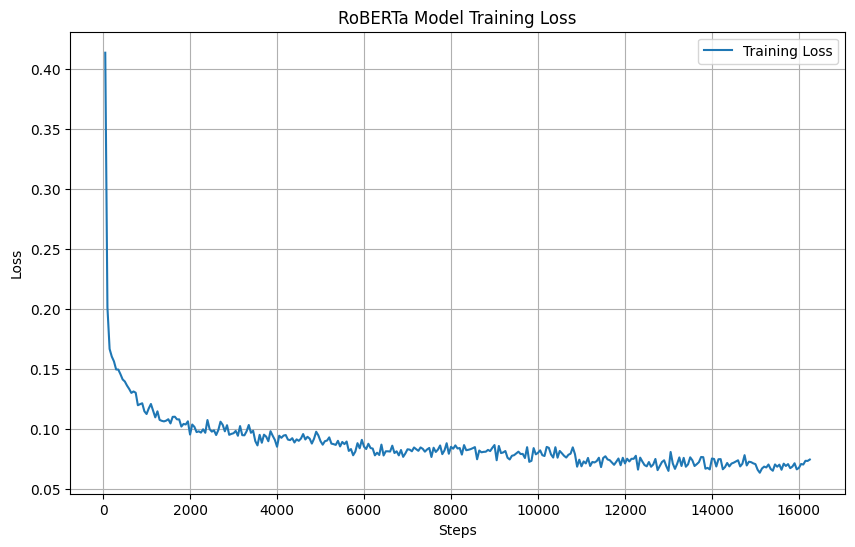

In [32]:
import matplotlib.pyplot as plt
import os

# Define the path to save the training loss graph
training_loss_graph_path = os.path.join(base_dir, 'outputs', 'training_loss.png')

# Extract logging history from the trainer
log_history = trainer.state.log_history

# Filter for training loss entries
train_losses = [entry['loss'] for entry in log_history if 'loss' in entry]
steps = [entry['step'] for entry in log_history if 'loss' in entry]

# Plotting the training loss
plt.figure(figsize=(10, 6))
plt.plot(steps, train_losses, label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('RoBERTa Model Training Loss')
plt.legend()
plt.grid(True)

# Save the plot
try:
    plt.savefig(training_loss_graph_path)
    print(f"Training loss graph saved to {training_loss_graph_path}")
except Exception as e:
    print(f"Error saving training loss graph: {e}")
plt.show()

### 6.2. Generate and Save Emotion Distribution Graph

We will visualize the distribution of emotions in the training dataset to understand label frequency. This graph will also be saved to the `outputs/` folder.

/tmp/ipykernel_1509/2524062030.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_names, y=label_counts.values, palette='viridis')


Emotion distribution graph saved to /content/gdrive/MyDrive/MentalHealthEmotionDetection/outputs/emotion_distribution.png


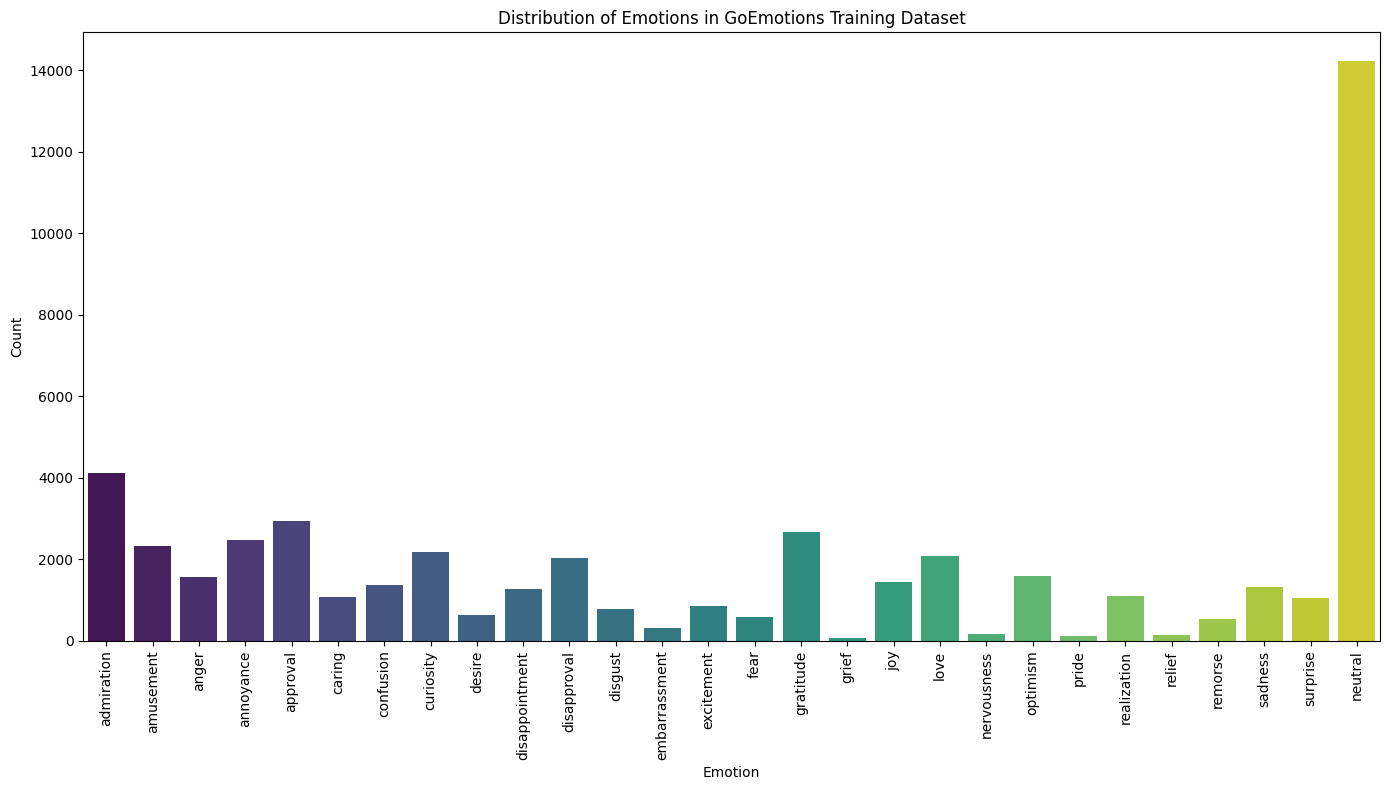

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the path to save the emotion distribution graph
emotion_dist_graph_path = os.path.join(base_dir, 'outputs', 'emotion_distribution.png')

# Flatten the list of lists of labels and count occurrences
all_labels = [label_id for sublist in dataset['train']['labels'] for label_id in sublist]
label_counts = pd.Series(all_labels).value_counts().sort_index()

# Map label IDs to emotion names
# Ensure emotion_labels list is available from previous cells
if 'emotion_labels' not in globals():
    emotion_labels = [
        "admiration", "amusement", "anger", "annoyance",
        "approval", "caring", "confusion", "curiosity",
        "desire", "disappointment", "disapproval", "disgust",
        "embarrassment", "excitement", "fear", "gratitude",
        "grief", "joy", "love", "nervousness",
        "optimism", "pride", "realization", "relief",
        "remorse", "sadness", "surprise", "neutral"
    ]

emotion_names = [emotion_labels[i] for i in label_counts.index]

# Plotting the emotion distribution
plt.figure(figsize=(14, 8))
sns.barplot(x=emotion_names, y=label_counts.values, palette='viridis')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Distribution of Emotions in GoEmotions Training Dataset')
plt.xticks(rotation=90)
plt.tight_layout()

# Save the plot
try:
    plt.savefig(emotion_dist_graph_path)
    print(f"Emotion distribution graph saved to {emotion_dist_graph_path}")
except Exception as e:
    print(f"Error saving emotion distribution graph: {e}")
plt.show()

### 7. Save Confusion Matrix Image into `outputs/` (Classification Report Visualization)

For multi-label classification, a standard confusion matrix is not directly applicable. Instead, we'll generate a comprehensive classification report (precision, recall, F1-score for each label) on the test set and visualize it. This provides a better understanding of the model's performance per emotion.

DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32


DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor after to(float32): torch.float32
DEBUG: Type of stacked labels: torch.float32
DEBUG: Original type of first label tensor in batch: torch.float32
DEBUG: Type of first label tensor afte

/tmp/ipykernel_1509/1592767033.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_for_plot, y=f1_values, palette='coolwarm')


Classification report F1-score plot saved to /content/gdrive/MyDrive/MentalHealthEmotionDetection/outputs/classification_report.png


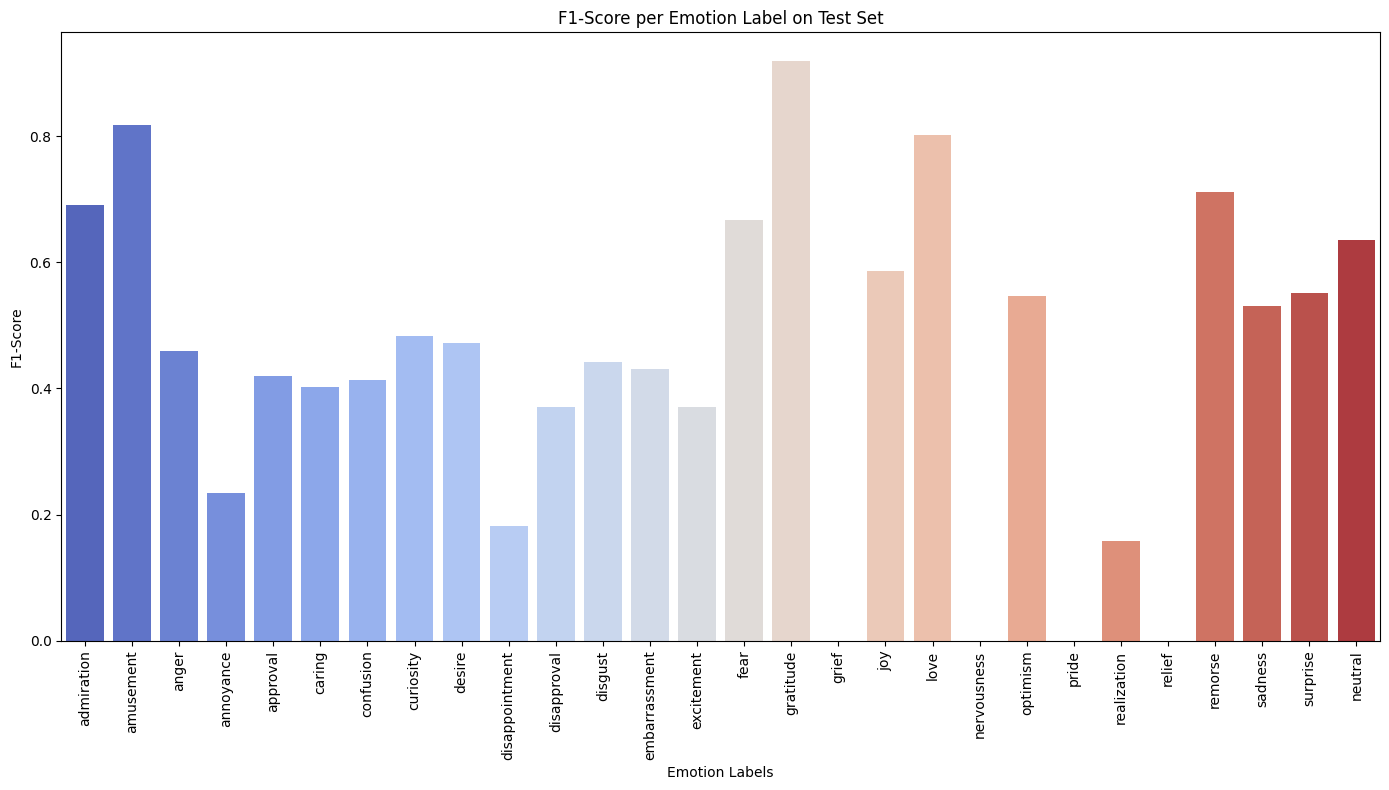

In [34]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Define the path to save the classification report image
classification_report_path = os.path.join(base_dir, 'outputs', 'classification_report.png')
classification_report_txt_path = os.path.join(base_dir, 'outputs', 'classification_report.txt')

# Make predictions on the test dataset
predictions = trainer.predict(tokenized_datasets["test"])
logits = predictions.predictions
probabilities = torch.sigmoid(torch.tensor(logits))

# Convert probabilities to binary predictions (threshold 0.5)
binary_predictions = (probabilities > 0.5).int().cpu().numpy()

# Get true labels from the test dataset
true_labels = tokenized_datasets["test"]["labels"]
# Convert true_labels to numpy array and ensure it's integers for scikit-learn
true_labels_np = np.array([t.tolist() for t in true_labels])

# Generate classification report
report = classification_report(
    true_labels_np, binary_predictions, target_names=emotion_labels, zero_division=0
)
print("\nClassification Report:\n", report)

# Save classification report to a text file
try:
    with open(classification_report_txt_path, 'w') as f:
        f.write(report)
    print(f"Classification report text saved to {classification_report_txt_path}")
except Exception as e:
    print(f"Error saving classification report text: {e}")

# Visualize the classification report (e.g., F1-score per label)
report_dict = classification_report(
    true_labels_np, binary_predictions, target_names=emotion_labels, output_dict=True, zero_division=0
)

# Extract F1-scores for plotting
f1_scores = {label: report_dict[label]['f1-score'] for label in emotion_labels}
labels_for_plot = list(f1_scores.keys())
f1_values = list(f1_scores.values())

plt.figure(figsize=(14, 8))
sns.barplot(x=labels_for_plot, y=f1_values, palette='coolwarm')
plt.xlabel('Emotion Labels')
plt.ylabel('F1-Score')
plt.title('F1-Score per Emotion Label on Test Set')
plt.xticks(rotation=90)
plt.tight_layout()

# Save the plot
try:
    plt.savefig(classification_report_path)
    print(f"Classification report F1-score plot saved to {classification_report_path}")
except Exception as e:
    print(f"Error saving classification report F1-score plot: {e}")
plt.show()

### 8. Create a Simple Streamlit `app.py` File inside `app/`

This `app.py` will contain the basic Streamlit application code to load the model and tokenizer, and allow users to input text for emotion prediction.

In [35]:
import os

app_file_path = os.path.join(base_dir, 'app', 'app.py')

app_content = f"""
import streamlit as st
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
import numpy as np

# Load model and tokenizer
@st.cache_resource
def load_model_and_tokenizer():
    model_path = "{os.path.join(base_dir, 'models', 'roberta_goemotions_model')}"
    tokenizer_path = "{os.path.join(base_dir, 'models', 'roberta_goemotions_tokenizer')}"
    tokenizer = RobertaTokenizer.from_pretrained(tokenizer_path)
    model = RobertaForSequenceClassification.from_pretrained(model_path)
    # Move model to CPU explicitly if running on Streamlit Cloud (no GPU)
    model.eval() # Set model to evaluation mode
    return tokenizer, model

tokenizer, model = load_model_and_tokenizer()

# Define emotion labels (must be in the same order as during training)
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance",
    "approval", "caring", "confusion", "curiosity",
    "desire", "disappointment", "disapproval", "disgust",
    "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief",
    "remorse", "sadness", "surprise", "neutral"
]

def predict_emotion(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # No need to move to model.device if model is already on CPU as set above
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.sigmoid(outputs.logits)[0]

    predictions = []
    for i, prob in enumerate(probs):
        if prob > 0.5:
            predictions.append(
                (emotion_labels[i], round(prob.item(), 4))
            )
    # Sort predictions by probability in descending order
    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions

st.set_page_config(page_title="Mental Health Emotion Detector", page_icon=":brain:")

st.title("🧠 Mental Health Emotion Detector")
st.markdown(
    "This application detects emotions in text using a fine-tuned RoBERTa model."
    "Enter some text below to see the predicted emotions and their confidence scores."
)

user_input = st.text_area("Enter text here:", "I am so happy and excited about this project!")

if st.button("Analyze Emotion"):
    if user_input:
        st.subheader("Predicted Emotions:")
        prediction = predict_emotion(user_input)
        if prediction:
            for emotion, score in prediction:
                st.write(f"- **{emotion.capitalize()}**: {score:.2f}")
        else:
            st.write("No strong emotions detected (all probabilities below 0.5).")
    else:
        st.warning("Please enter some text to analyze.")

st.markdown("---<br>Developed by Your Name/Organization", unsafe_allow_html=True)
"""

try:
    with open(app_file_path, 'w') as f:
        f.write(app_content)
    print(f"Streamlit app.py created successfully at {app_file_path}")
except Exception as e:
    print(f"Error creating Streamlit app.py: {e}")

Streamlit app.py created successfully at /content/gdrive/MyDrive/MentalHealthEmotionDetection/app/app.py


### 9. Create `requirements.txt` for Deployment

This file lists all the Python dependencies required to run the Streamlit application.